<a href="https://www.kaggle.com/code/lalit7881/enhanced-superstore-sales-eda?scriptVersionId=323572900" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sumeakash/enhanced-superstore-sales-dataset/Global Superstore.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sumeakash/enhanced-superstore-sales-dataset/Global Superstore.csv")

In [3]:
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [4]:
df.tail()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
51285,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,00:00.0,CA-2014-109701,...,69,Corporate,00:00.0,Same Day,5.15,California,Binders,2014,North America,49
51286,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,00:00.0,CA-2014-109701,...,9,Corporate,00:00.0,Same Day,0.44,California,Binders,2014,North America,49
51287,Office Supplies,Los Angeles,United States,HR-147704,Hallie Redmond,0.2,US,1,00:00.0,CA-2014-106964,...,12,Home Office,00:00.0,First Class,0.31,California,Binders,2014,North America,51
51288,Office Supplies,Los Angeles,United States,RM-196754,Robert Marley,0.2,US,1,00:00.0,CA-2014-145219,...,90,Home Office,00:00.0,First Class,15.95,California,Binders,2014,North America,52
51289,Office Supplies,Los Angeles,United States,FH-143654,Fred Hopkins,0.2,US,1,00:00.0,CA-2014-121398,...,154,Corporate,00:00.0,Standard Class,9.59,California,Binders,2014,North America,52


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer ID     51290 non-null  object 
 4   Customer Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   ji_lu-shu       51290 non-null  int64  
 8   Order Date      51290 non-null  object 
 9   Order ID        51290 non-null  object 
 10  Order Priority  51290 non-null  object 
 11  Product ID      51290 non-null  object 
 12  Product Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [6]:
df.describe()

,Discount,ji_lu-shu,Profit,Quantity,Row ID,Sales,Shipping Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [7]:
df.isnull()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
51286,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
51287,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
51288,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer ID       0
Customer Name     0
Discount          0
Market            0
ji_lu-shu         0
Order Date        0
Order ID          0
Order Priority    0
Product ID        0
Product Name      0
Profit            0
Quantity          0
Region            0
Row ID            0
Sales             0
Segment           0
Ship Date         0
Ship Mode         0
Shipping Cost     0
State             0
Sub-Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Category           object
City               object
Country            object
Customer ID        object
Customer Name      object
Discount          float64
Market             object
ji_lu-shu           int64
Order Date         object
Order ID           object
Order Priority     object
Product ID         object
Product Name       object
Profit            float64
Quantity            int64
Region             object
Row ID              int64
Sales               int64
Segment            object
Ship Date          object
Ship Mode          object
Shipping Cost     float64
State              object
Sub-Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object

In [11]:
df.shape

(51290, 27)

In [12]:
df.columns

Index(['Category', 'City', 'Country', 'Customer ID', 'Customer Name',
       'Discount', 'Market', 'ji_lu-shu', 'Order Date', 'Order ID',
       'Order Priority', 'Product ID', 'Product Name', 'Profit', 'Quantity',
       'Region', 'Row ID', 'Sales', 'Segment', 'Ship Date', 'Ship Mode',
       'Shipping Cost', 'State', 'Sub-Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [13]:
df.nunique()

Category              3
City               3636
Country             147
Customer ID        4873
Customer Name       795
Discount             27
Market                7
ji_lu-shu             1
Order Date            1
Order ID          25035
Order Priority        4
Product ID        10292
Product Name       3788
Profit            24575
Quantity             14
Region               13
Row ID            51290
Sales              2246
Segment               3
Ship Date             1
Ship Mode             4
Shipping Cost     16877
State              1094
Sub-Category         17
Year                  4
Market2               6
weeknum              53
dtype: int64

## EDA

In [14]:
# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df.shape)
print(df.info())

(51290, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  object        
 1   City            51290 non-null  object        
 2   Country         51290 non-null  object        
 3   Customer ID     51290 non-null  object        
 4   Customer Name   51290 non-null  object        
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  object        
 7   ji_lu-shu       51290 non-null  int64         
 8   Order Date      51290 non-null  datetime64[ns]
 9   Order ID        51290 non-null  object        
 10  Order Priority  51290 non-null  object        
 11  Product ID      51290 non-null  object        
 12  Product Name    51290 non-null  object        
 13  Profit          51290 non-null  float64       
 14  Quantity        51290 non-null  int64     

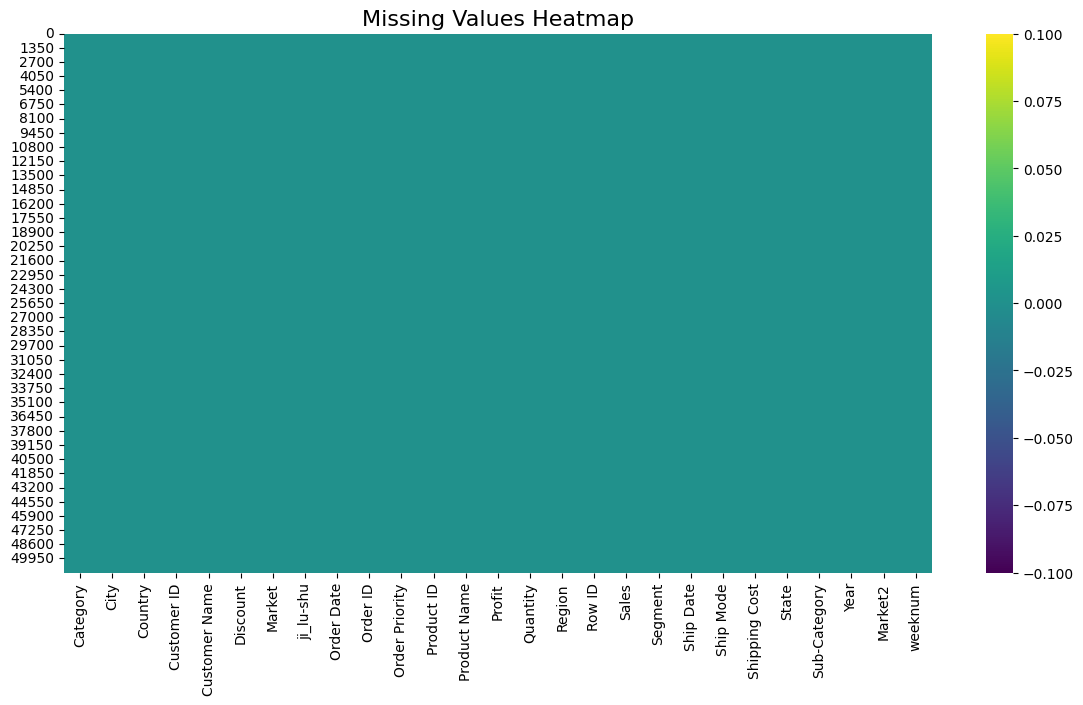

In [15]:
plt.figure(figsize=(14,7))
sns.heatmap(df.isnull(),
            cbar=True,
            cmap='viridis')

plt.title('Missing Values Heatmap', fontsize=16)
plt.show()

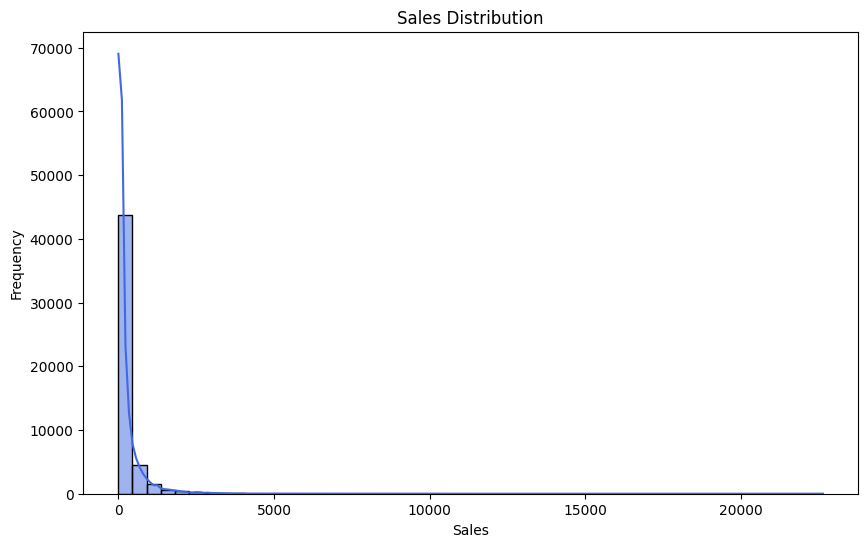

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(df['Sales'],
             bins=50,
             kde=True,
             color='royalblue')

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

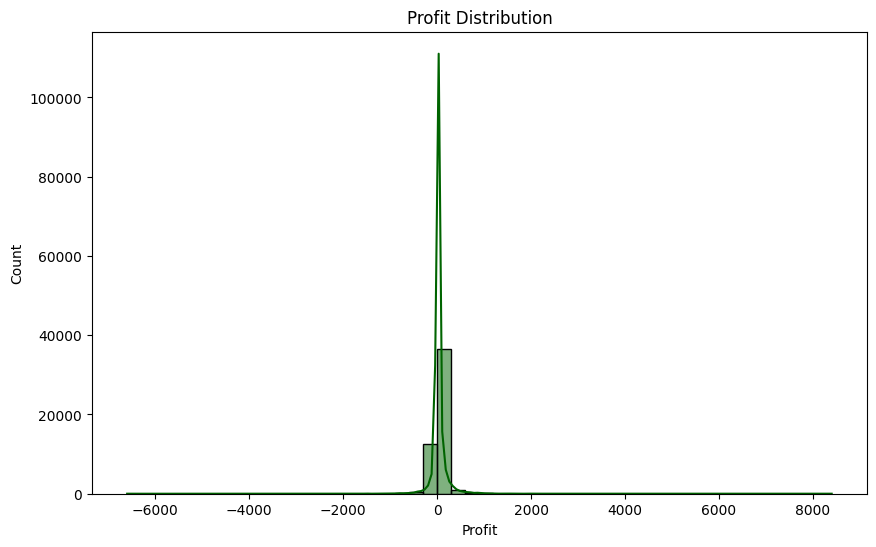

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(df['Profit'],
             bins=50,
             kde=True,
             color='darkgreen')

plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Count')
plt.show()

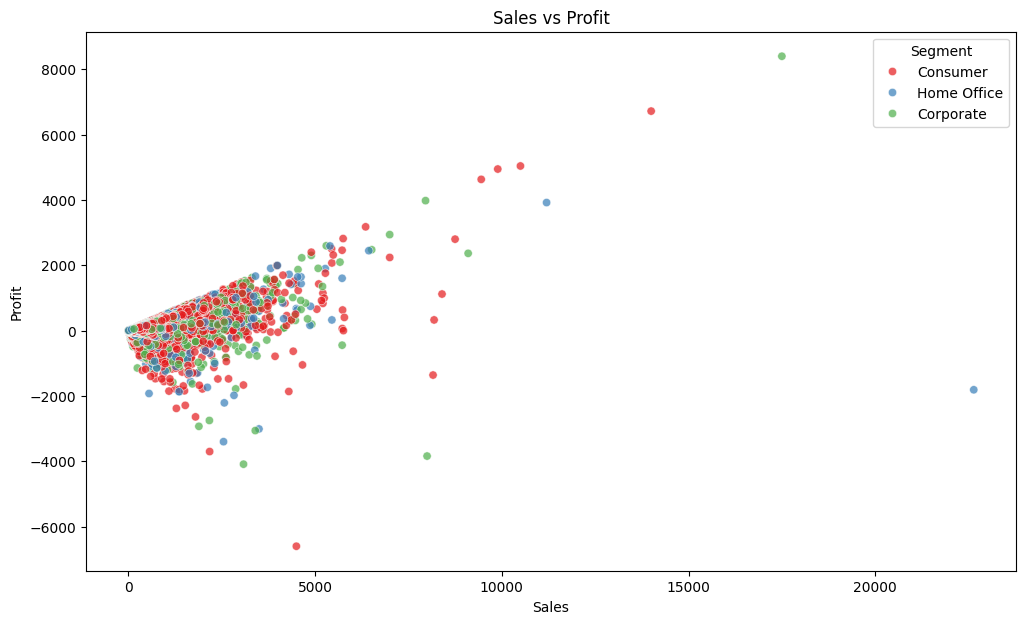

In [18]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Segment',
    palette='Set1',
    alpha=0.7
)

plt.title('Sales vs Profit')
plt.show()

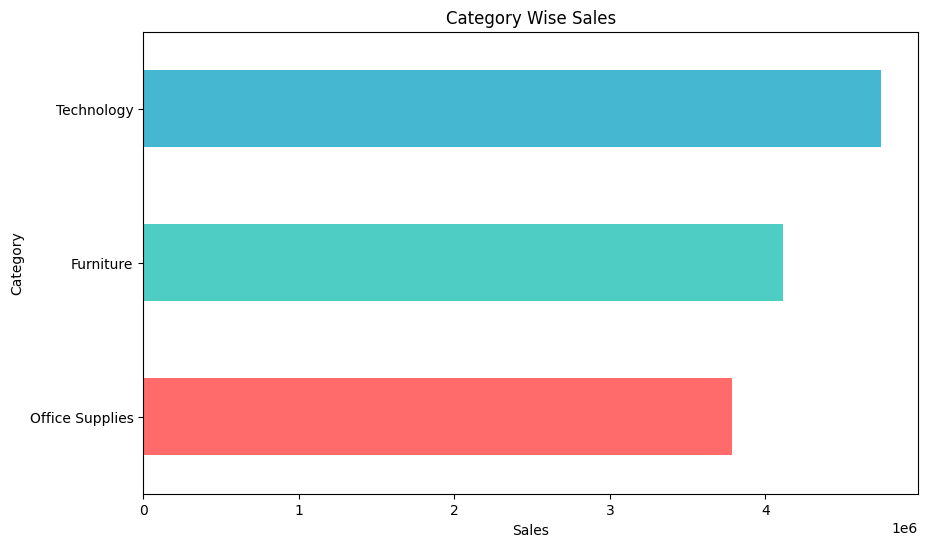

In [19]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

plt.figure(figsize=(10,6))

category_sales.plot(
    kind='barh',
    color=['#FF6B6B','#4ECDC4','#45B7D1']
)

plt.title('Category Wise Sales')
plt.xlabel('Sales')
plt.show()

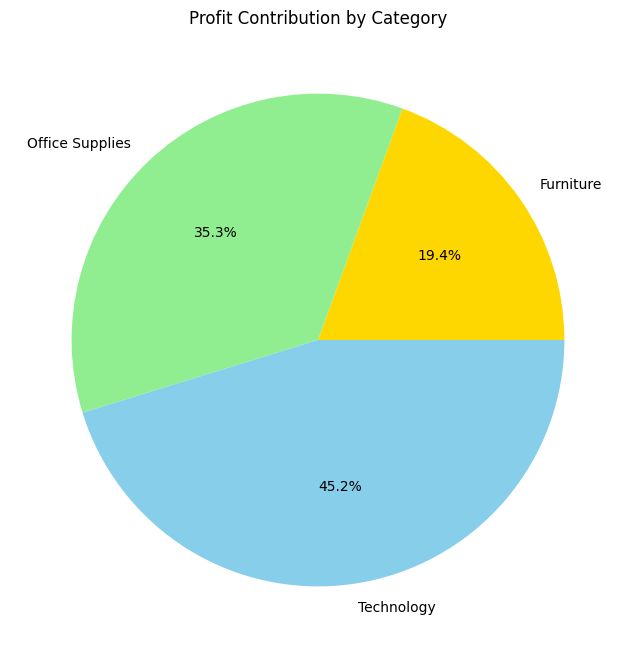

In [20]:
category_profit = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    category_profit,
    labels=category_profit.index,
    autopct='%1.1f%%',
    colors=['gold','lightgreen','skyblue']
)

plt.title('Profit Contribution by Category')
plt.show()

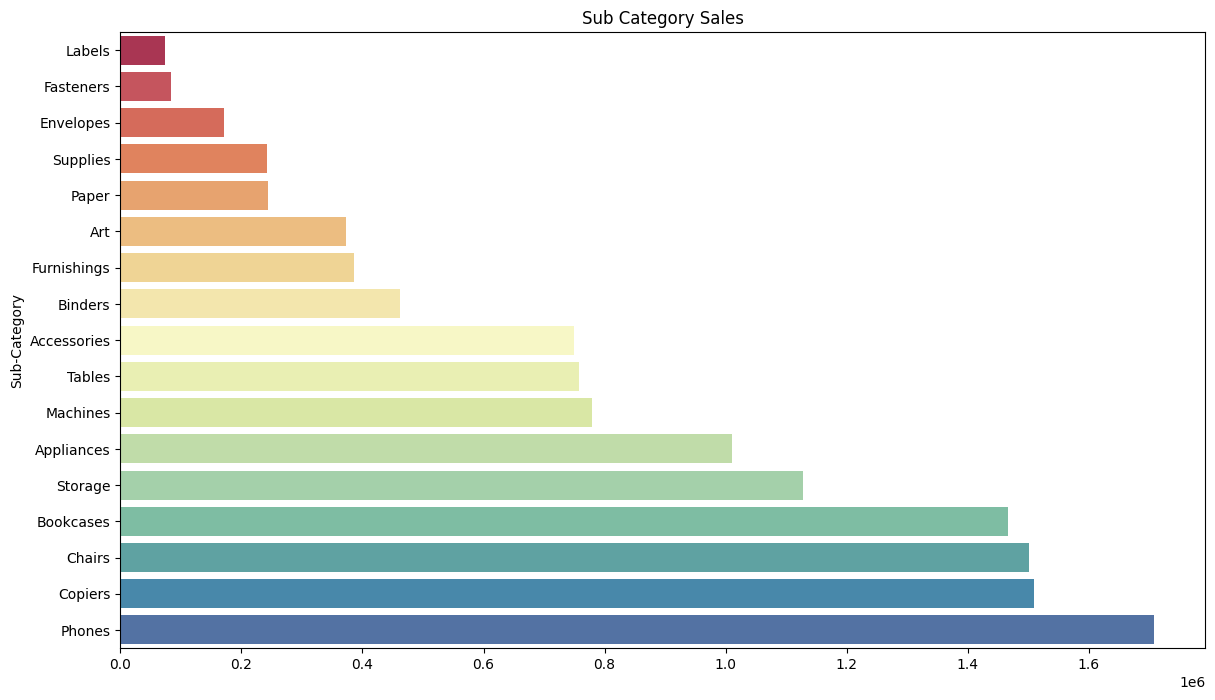

In [21]:
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values()

plt.figure(figsize=(14,8))

sns.barplot(
    x=subcat_sales.values,
    y=subcat_sales.index,
    palette='Spectral'
)

plt.title('Sub Category Sales')
plt.show()

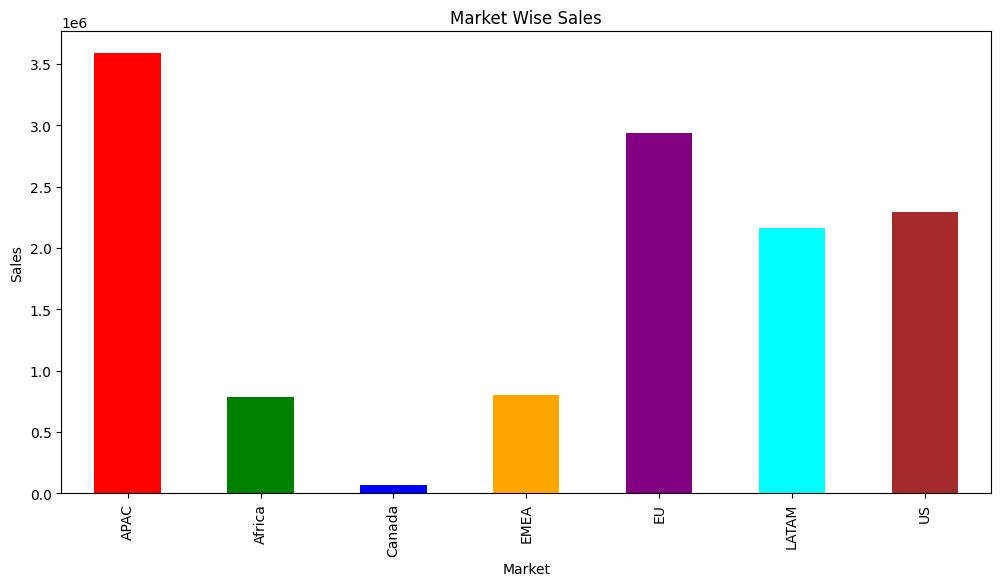

In [22]:
plt.figure(figsize=(12,6))

market_sales = df.groupby('Market')['Sales'].sum()

market_sales.plot(
    kind='bar',
    color=['red','green','blue','orange','purple','cyan','brown']
)

plt.title('Market Wise Sales')
plt.ylabel('Sales')
plt.show()

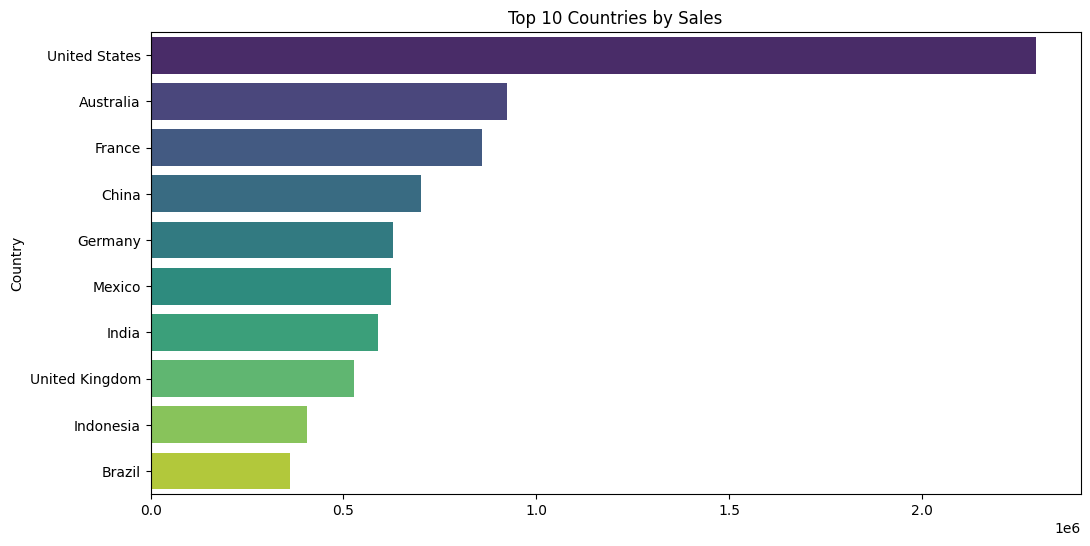

In [23]:
country_sales = (
    df.groupby('Country')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index,
    palette='viridis'
)

plt.title('Top 10 Countries by Sales')
plt.show()

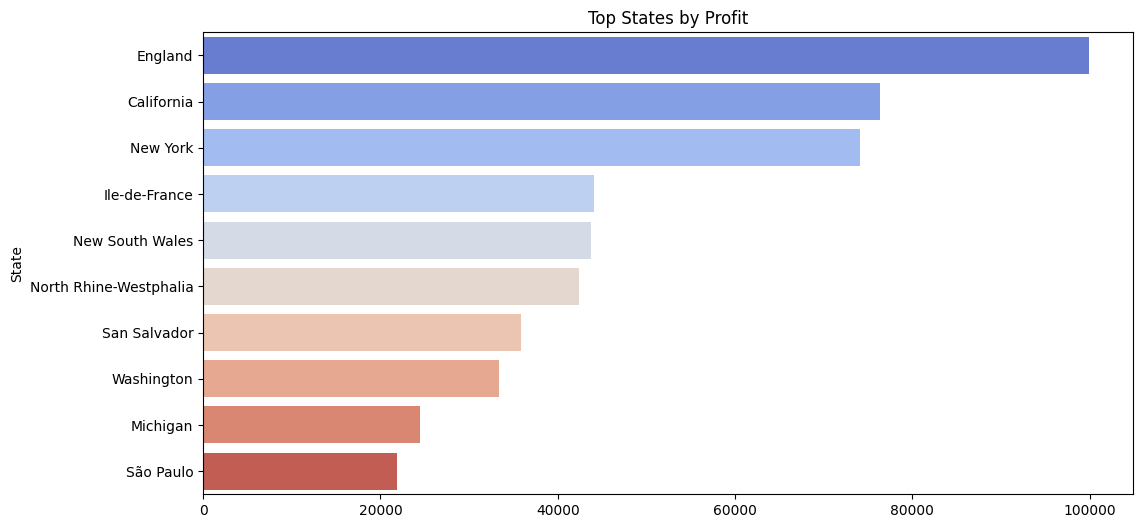

In [24]:
state_profit = (
    df.groupby('State')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_profit.values,
    y=state_profit.index,
    palette='coolwarm'
)

plt.title('Top States by Profit')
plt.show()

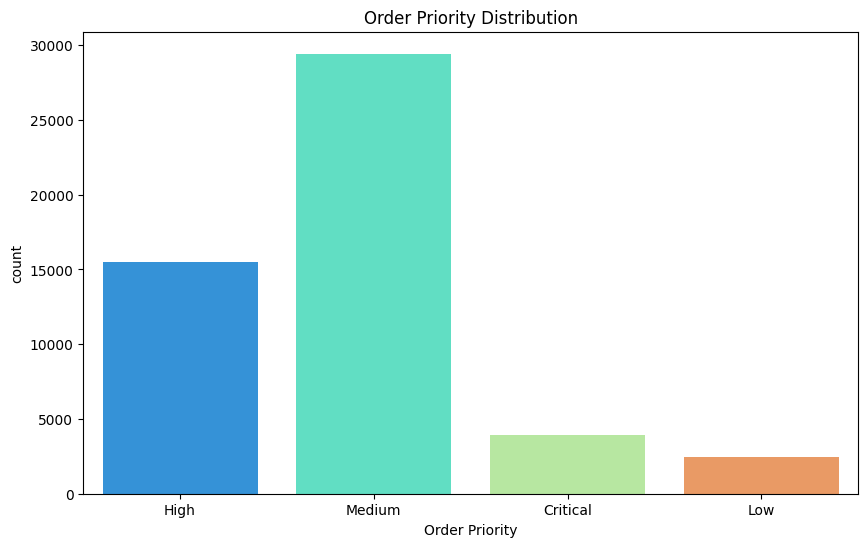

In [25]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Order Priority',
    palette='rainbow'
)

plt.title('Order Priority Distribution')
plt.show()

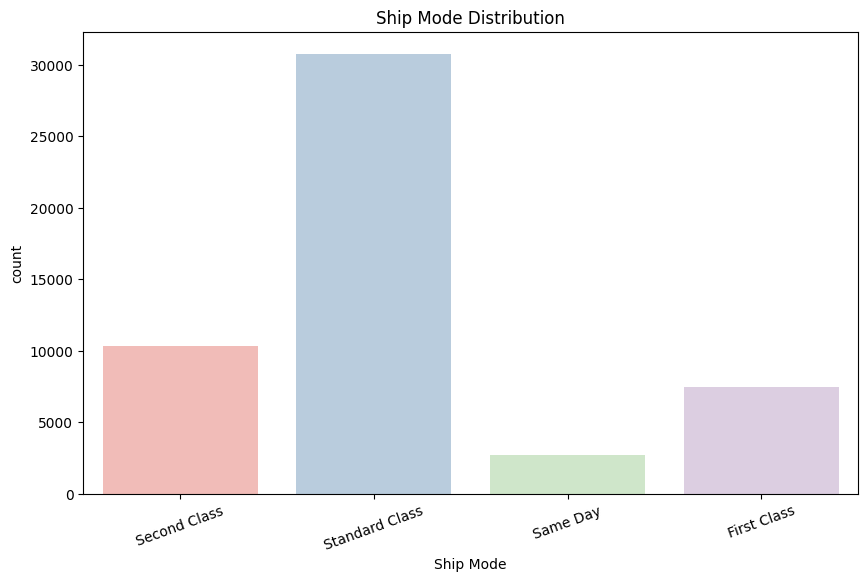

In [26]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Ship Mode',
    palette='Pastel1'
)

plt.xticks(rotation=20)
plt.title('Ship Mode Distribution')
plt.show()

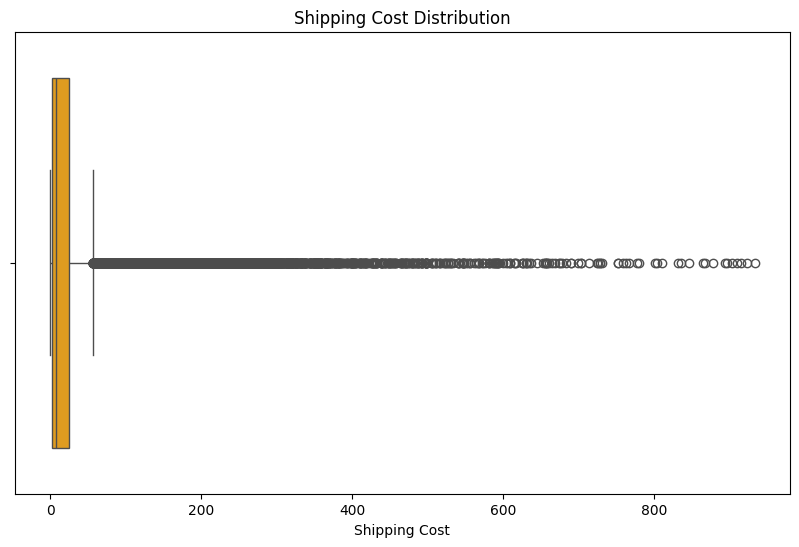

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['Shipping Cost'],
    color='orange'
)

plt.title('Shipping Cost Distribution')
plt.show()

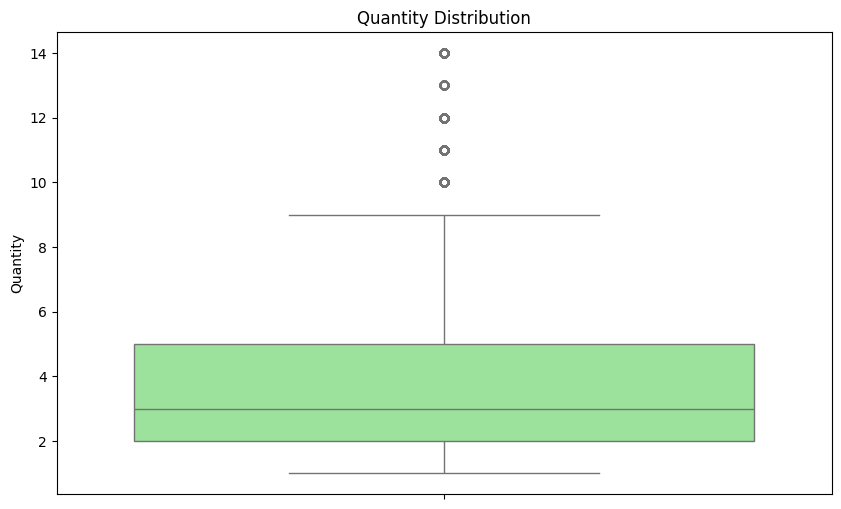

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(
    y=df['Quantity'],
    color='lightgreen'
)

plt.title('Quantity Distribution')
plt.show()

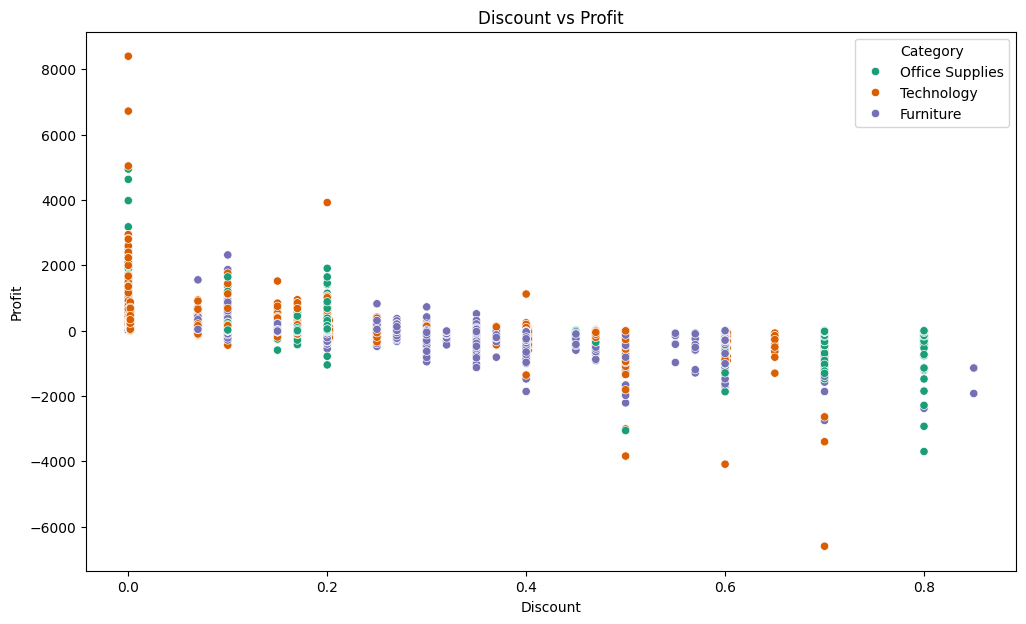

In [29]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',
    palette='Dark2'
)

plt.title('Discount vs Profit')
plt.show()

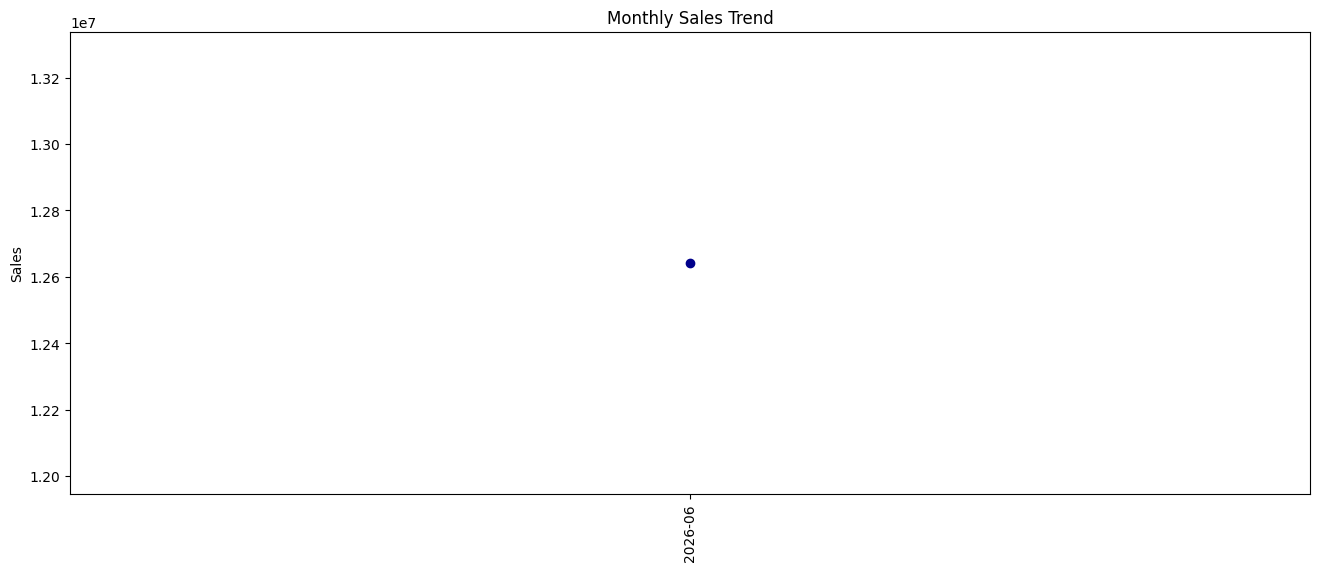

In [30]:
monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(16,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    color='darkblue'
)

plt.xticks(rotation=90)

plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()

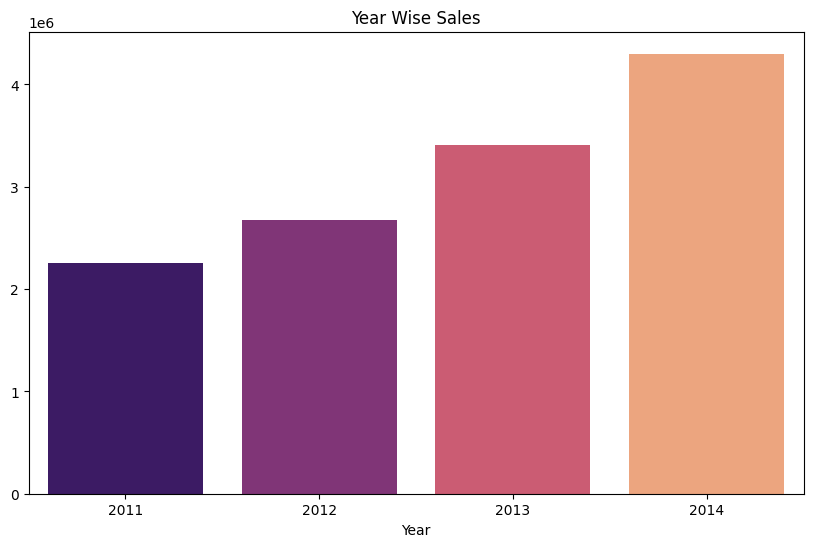

In [31]:
year_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(10,6))

sns.barplot(
    x=year_sales.index,
    y=year_sales.values,
    palette='magma'
)

plt.title('Year Wise Sales')
plt.show()

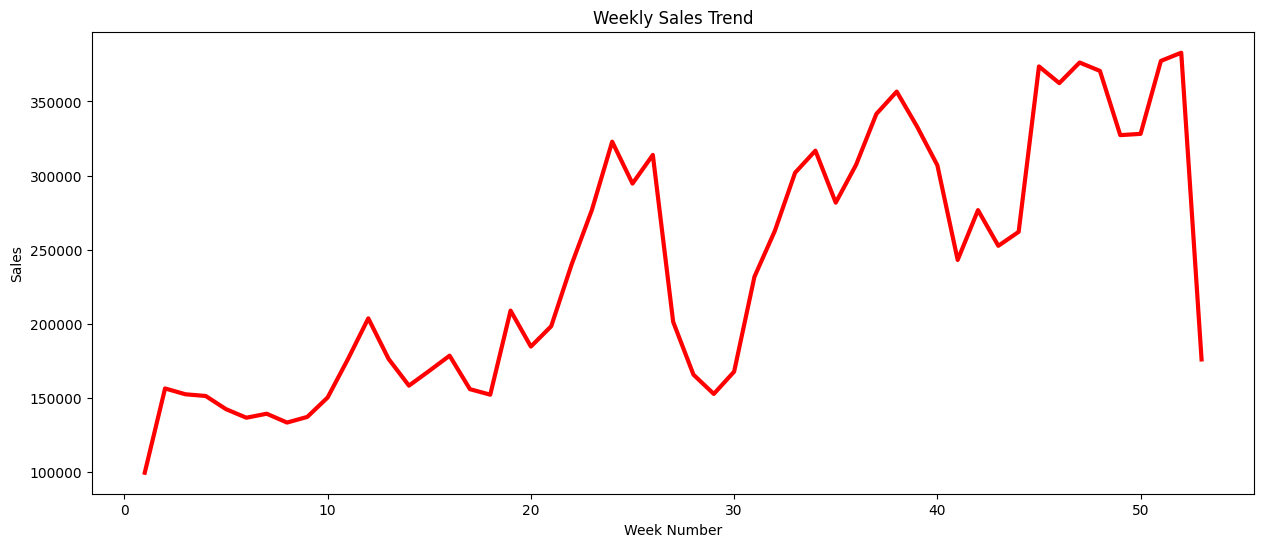

In [32]:
weekly_sales = df.groupby('weeknum')['Sales'].sum()

plt.figure(figsize=(15,6))

sns.lineplot(
    x=weekly_sales.index,
    y=weekly_sales.values,
    color='red',
    linewidth=3
)

plt.title('Weekly Sales Trend')
plt.xlabel('Week Number')
plt.ylabel('Sales')
plt.show()

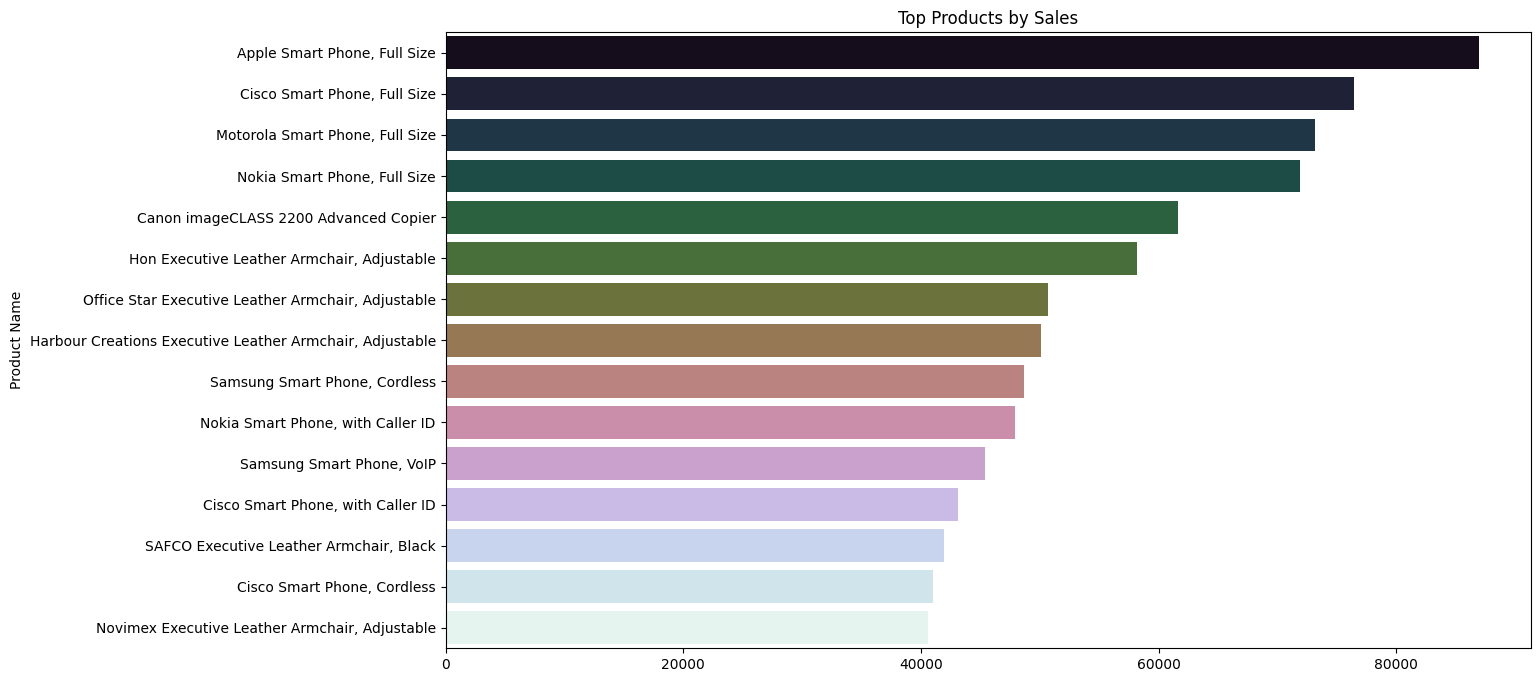

In [33]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,8))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette='cubehelix'
)

plt.title('Top Products by Sales')
plt.show()

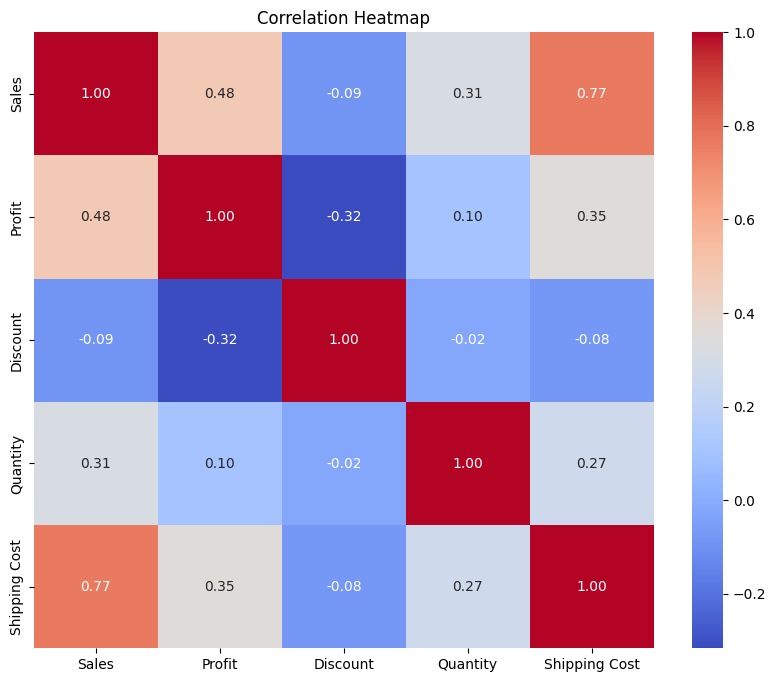

In [34]:
num_cols = [
    'Sales',
    'Profit',
    'Discount',
    'Quantity',
    'Shipping Cost'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

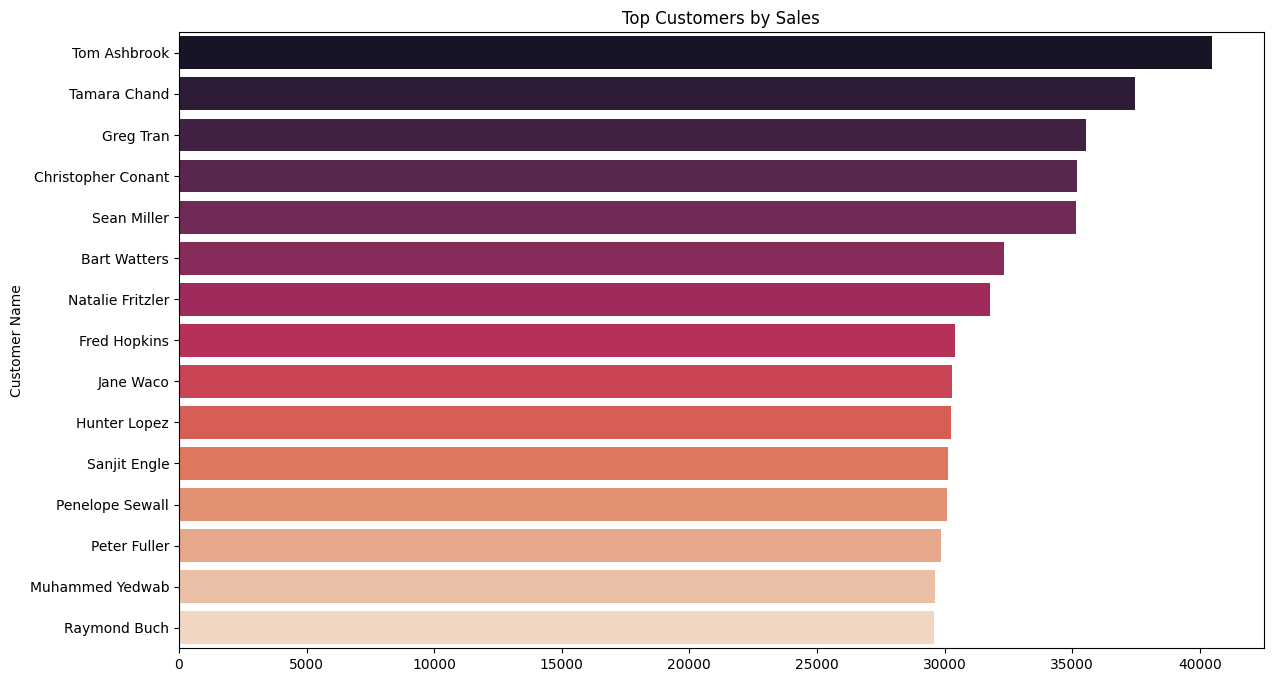

In [35]:
top_customers = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,8))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index,
    palette='rocket'
)

plt.title('Top Customers by Sales')
plt.show()

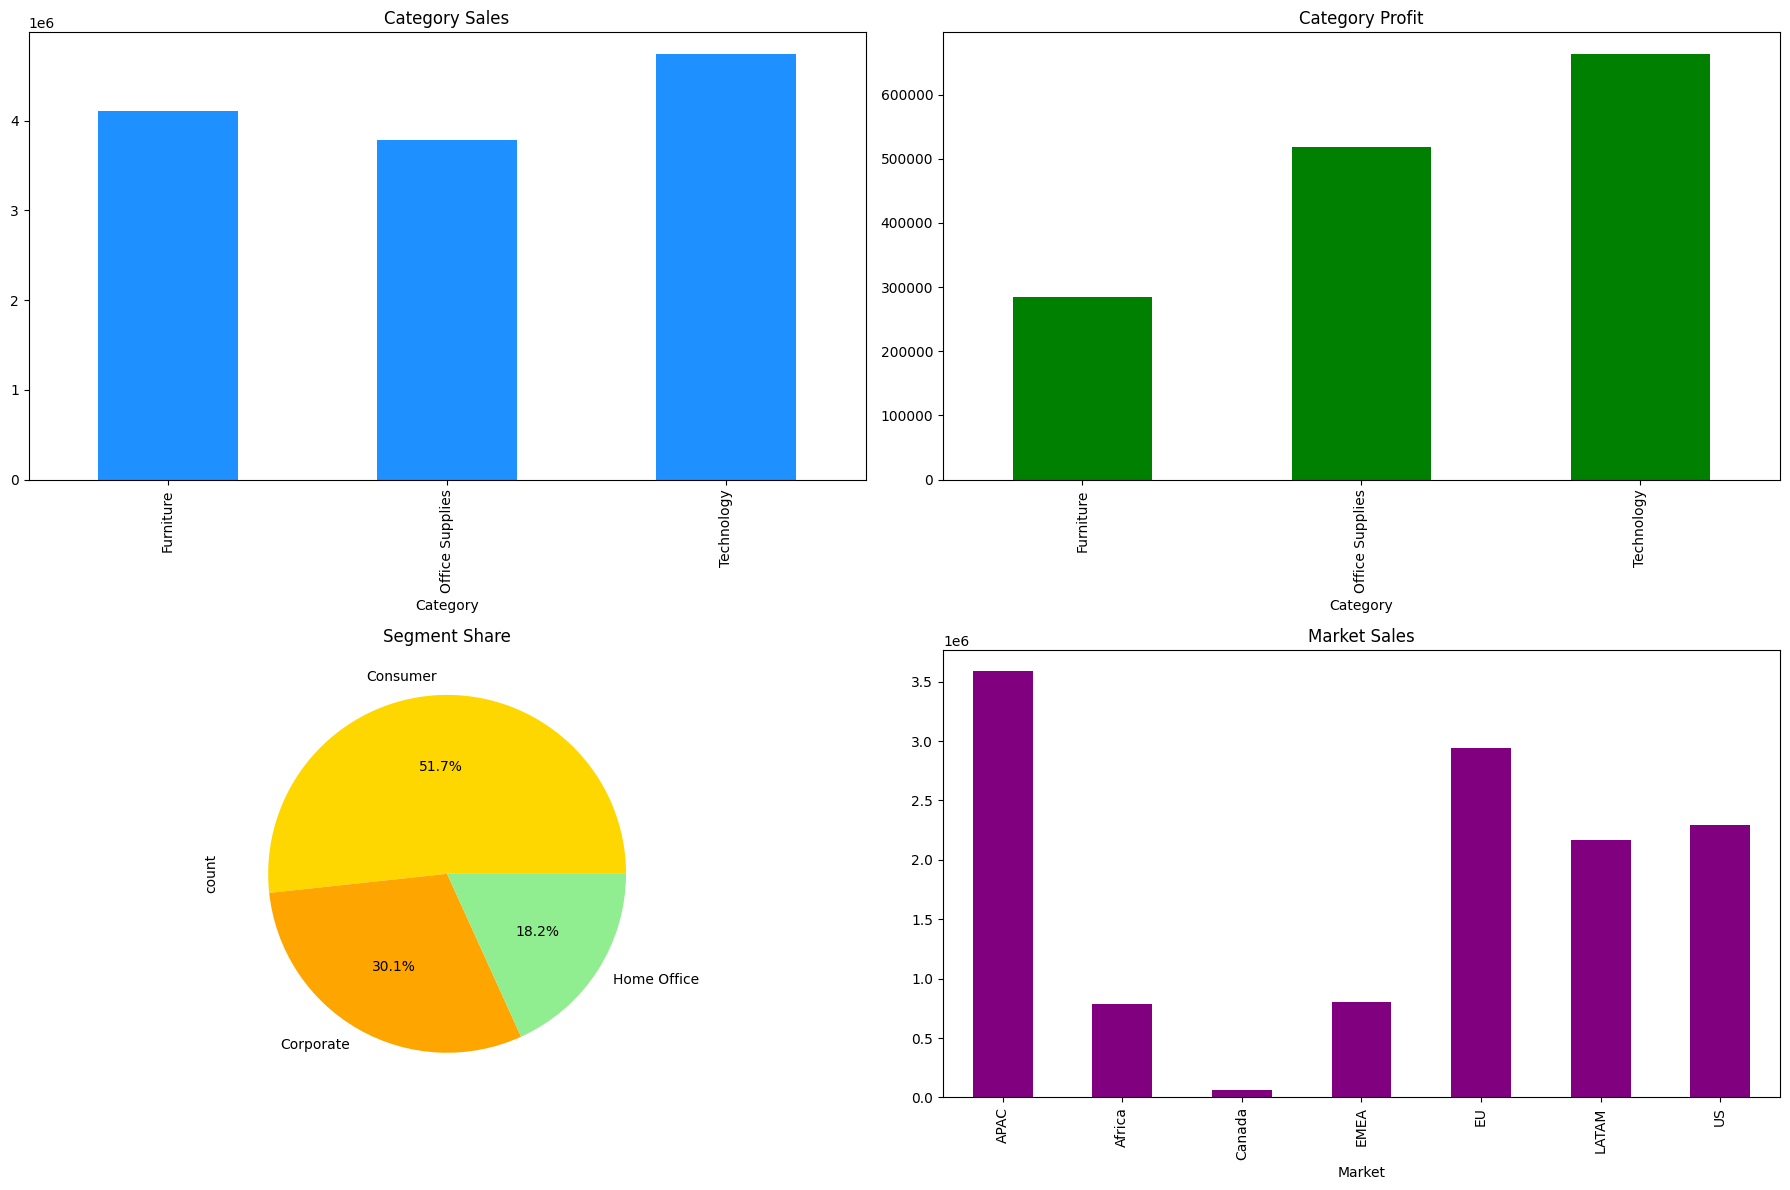

In [36]:
fig, ax = plt.subplots(2,2, figsize=(18,12))

# Sales
df.groupby('Category')['Sales'].sum().plot(
    kind='bar',
    color='dodgerblue',
    ax=ax[0,0]
)
ax[0,0].set_title('Category Sales')

# Profit
df.groupby('Category')['Profit'].sum().plot(
    kind='bar',
    color='green',
    ax=ax[0,1]
)
ax[0,1].set_title('Category Profit')

# Segment
df['Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=ax[1,0],
    colors=['gold','orange','lightgreen']
)
ax[1,0].set_title('Segment Share')

# Market
df.groupby('Market')['Sales'].sum().plot(
    kind='bar',
    color='purple',
    ax=ax[1,1]
)
ax[1,1].set_title('Market Sales')

plt.tight_layout()
plt.show()

## Feature engineering

In [37]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)

Dataset Shape: (51290, 23)
Target Distribution:
Profit_Target
1    38078
0    13212
Name: count, dtype: int64

Numerical Features
['Discount', 'ji_lu-shu', 'Quantity', 'Sales', 'Shipping Cost', 'Year', 'weeknum', 'Shipping_Days']

Categorical Features
['Category', 'City', 'Country', 'Market', 'Order Priority', 'Region', 'Segment', 'Ship Mode', 'State', 'Sub-Category', 'Market2']

Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training Extra Trees...

Training AdaBoost...


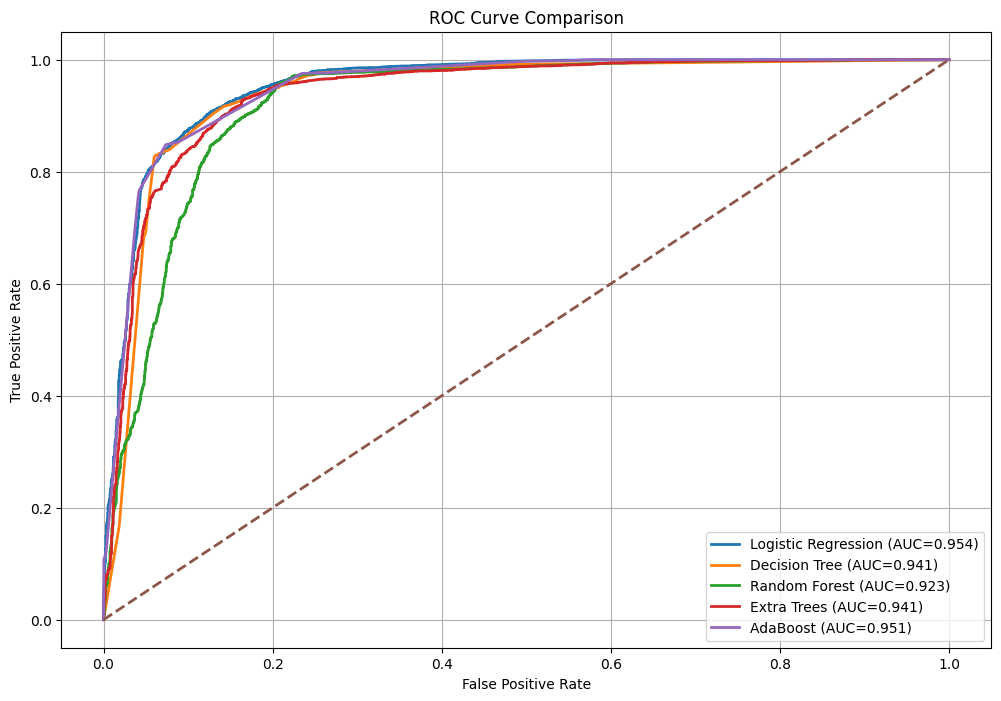



MODEL PERFORMANCE
                 Model  Accuracy  Precision  Recall      F1  ROC_AUC
0  Logistic Regression    0.9188     0.9234  0.9712  0.9467   0.9540
4             AdaBoost    0.9214     0.9231  0.9754  0.9485   0.9511
1        Decision Tree    0.9166     0.9208  0.9711  0.9453   0.9408
3          Extra Trees    0.7854     0.7764  0.9986  0.8736   0.9408
2        Random Forest    0.8135     0.8004  0.9975  0.8882   0.9234

Best Model: Logistic Regression


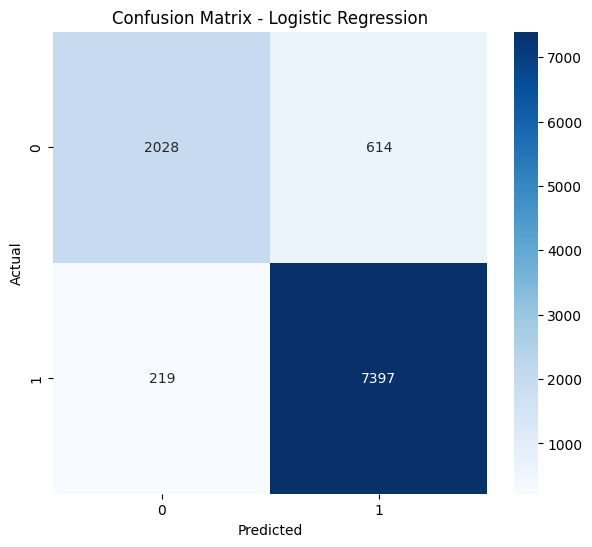



CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      2642
           1       0.92      0.97      0.95      7616

    accuracy                           0.92     10258
   macro avg       0.91      0.87      0.89     10258
weighted avg       0.92      0.92      0.92     10258



In [38]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Order_Month'] = df['Order Date'].dt.month
df['Order_Day'] = df['Order Date'].dt.day
df['Order_Weekday'] = df['Order Date'].dt.weekday

df['Shipping_Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

# ==========================================================
# TARGET
# ==========================================================

df['Profit_Target'] = np.where(
    df['Profit'] > 0,
    1,
    0
)

# ==========================================================
# REMOVE LEAKAGE
# ==========================================================

leakage_cols = [
    'Profit',
    'Order Date',
    'Ship Date'
]

df.drop(columns=leakage_cols, inplace=True)

# ==========================================================
# REMOVE HIGH CARDINALITY ID COLUMNS
# ==========================================================

drop_cols = [
    'Customer ID',
    'Customer Name',
    'Order ID',
    'Product ID',
    'Product Name',
    'Row ID'
]

existing_cols = [c for c in drop_cols if c in df.columns]

df.drop(columns=existing_cols, inplace=True)

# ==========================================================
# FEATURES & TARGET
# ==========================================================

X = df.drop('Profit_Target', axis=1)
y = df['Profit_Target']

print("="*60)
print("Dataset Shape:", df.shape)
print("Target Distribution:")
print(y.value_counts())
print("="*60)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ==========================================================
# NUMERIC / CATEGORICAL COLUMNS
# ==========================================================

numeric_features = X_train.select_dtypes(
    include=['int64','float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

print("\nNumerical Features")
print(numeric_features)

print("\nCategorical Features")
print(categorical_features)

# ==========================================================
# PREPROCESSING
# ==========================================================

numeric_transformer = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='most_frequent')
    ),
    (
        'encoder',
        OneHotEncoder(
            handle_unknown='ignore',
            min_frequency=10
        )
    )
])

preprocessor = ColumnTransformer([
    (
        'num',
        numeric_transformer,
        numeric_features
    ),
    (
        'cat',
        categorical_transformer,
        categorical_features
    )
])

# ==========================================================
# FAST MODELS
# ==========================================================

models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=300,
        random_state=42
    ),

    "Decision Tree":
    DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees":
    ExtraTreesClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost":
    AdaBoostClassifier(
        random_state=42
    )
}

# ==========================================================
# TRAINING
# ==========================================================

results = []

plt.figure(figsize=(12,8))

for name, model in models.items():

    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append([
        name,
        acc,
        precision,
        recall,
        f1,
        roc_auc
    ])

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{name} (AUC={roc_auc:.3f})'
    )

# ==========================================================
# ROC CURVE
# ==========================================================

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

# ==========================================================
# RESULTS
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC_AUC'
    ]
)

results_df = results_df.sort_values(
    by='ROC_AUC',
    ascending=False
)

print("\n")
print("="*70)
print("MODEL PERFORMANCE")
print("="*70)

print(results_df.round(4))

# ==========================================================
# BEST MODEL
# ==========================================================

best_model_name = results_df.iloc[0]['Model']

print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model)
])

best_pipeline.fit(X_train, y_train)

best_pred = best_pipeline.predict(X_test)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f'Confusion Matrix - {best_model_name}'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\n")
print("="*70)
print("CLASSIFICATION REPORT")
print("="*70)

print(
    classification_report(
        y_test,
        best_pred
    )
)

## Thank you....pls upvote!!!!!!!!!!!!!!!!!!!